# Goal

Explore recurring chart patterns to identify long-term dynamics in popular music.

The analyses focus on chart re-entries to uncover temporal and seasonal patterns and to generate hypotheses for subsequent analyses using Spotify metadata.

In [102]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [103]:
# Load Datasets

project_path = Path.cwd().parent
interim_path = project_path / 'data' / 'interim'

chart_history = pd.read_csv(interim_path/'uk_chart_history_clean.csv')
songs = pd.read_csv(interim_path/'songs.csv')
chart_statistics = pd.read_csv(interim_path/'chart_statistics.csv')

### Link Song Identifiers

Song identifiers are merged into the chart history to establish a stable relationship
between chart entries and song-based analyses.

In [104]:
chart_history = (chart_history
                 .merge(songs,
                        on=['Song', 'Artist'],
                        how='left')
                 )

chart_history = (chart_history[
    ['song_id',
     'Song',
     'Artist',
     'Position',
     'Last Week',
     'Peak',
     'Weeks on Chart',
     'Week']
])

chart_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 210882 entries, 0 to 210881
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   song_id         210837 non-null  float64
 1   Song            210882 non-null  str    
 2   Artist          210837 non-null  str    
 3   Position        210882 non-null  int64  
 4   Last Week       210882 non-null  str    
 5   Peak            210882 non-null  int64  
 6   Weeks on Chart  210882 non-null  int64  
 7   Week            210882 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 12.9 MB


In [105]:
songs.info()

<class 'pandas.DataFrame'>
RangeIndex: 36655 entries, 0 to 36654
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   song_id  36655 non-null  int64
 1   Song     36655 non-null  str  
 2   Artist   36655 non-null  str  
dtypes: int64(1), str(2)
memory usage: 859.2 KB


In [106]:
chart_statistics.info()

<class 'pandas.DataFrame'>
RangeIndex: 36655 entries, 0 to 36654
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   song_id               36655 non-null  int64
 1   Song                  36655 non-null  str  
 2   Artist                36655 non-null  str  
 3   peak_position         36655 non-null  int64
 4   total_chart_weeks     36655 non-null  int64
 5   observed_chart_weeks  36655 non-null  int64
 6   weeks_top_1           36655 non-null  int64
 7   weeks_top_10          36655 non-null  int64
 8   weeks_top_50          36655 non-null  int64
dtypes: int64(7), str(2)
memory usage: 2.5 MB


## Explore Last Week Status

The `Last Week` column contains information about a song's chart status in the
previous week.

This section explores the distribution of these status values and identifies
chart re-entries (`LW:RE`) for further analysis.

In [107]:
# Explore Last Week Entries

chart_history['Last Week'].value_counts().head(20)


Last Week
LW:New    36401
LW:RE     10297
LW:1       2139
LW:8       2139
LW:6       2138
LW:3       2138
LW:13      2138
LW:12      2138
LW:19      2138
LW:2       2137
LW:14      2137
LW:18      2136
LW:10      2136
LW:9       2136
LW:11      2136
LW:7       2135
LW:4       2134
LW:5       2133
LW:16      2133
LW:23      2133
Name: count, dtype: int64

In [108]:
# Identify Re-Entries

re_entry_count = (chart_history['Last Week'] == 'LW:RE').sum()
print(f'Number of chart re-entries: {re_entry_count}')

Number of chart re-entries: 10297


### Count Re-entries per Song

Re-entry events are aggregated by song to identify titles that repeatedly
returned to the charts over the observation period.

In [109]:
re_entries = (chart_history[chart_history['Last Week'] == 'LW:RE']
              .groupby('song_id')
              .size()
              .sort_values(ascending=False)
              )

re_entries.head(20)

song_id
24705.0    58
72.0       24
929.0      21
28523.0    20
12532.0    20
28337.0    19
26514.0    19
2738.0     19
12558.0    18
16733.0    18
27322.0    18
17554.0    17
30106.0    17
13822.0    17
28051.0    17
28356.0    17
26966.0    17
4775.0     17
28091.0    16
28056.0    16
dtype: int64

### Inspect the Most Frequent Re-entry

The song with the highest number of observed re-entries is identified to verify
the aggregation and provide an initial insight into long-term chart behaviour.

In [110]:
songs[songs['song_id'] == 24705]

,song_id,Song,Artist
24704,24705,MR BRIGHTSIDE,KILLERS


In [111]:
print(f'Songs with re-entries: {len(re_entries)}')
print(f'Share of songs with re-entries: {len(re_entries) / len(songs):.2%}')

Songs with re-entries: 6373
Share of songs with re-entries: 17.39%


## Create Re-entry History

All chart re-entry events are extracted into a separate dataset.

Only variables describing the individual re-entry event are retained, while
song-level statistics are handled separately in the chart statistics table.

This focused dataset serves as the basis for the following analyses of chart
positions, temporal patterns, and seasonal trends.

In [112]:
re_entry_history = (chart_history[
                    chart_history['Last Week'] == 'LW:RE'
                    ][['song_id',
                    'Song',
                    'Artist',
                    'Position',
                    'Last Week',
                    'Week']]
                    .copy()
                    )

re_entry_history.head()


,song_id,Song,Artist,Position,Last Week,Week
64,65.0,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,2 January 1983- 8 January 1983
74,75.0,LET'S GO TO BED,THE CURE,75,LW:RE,2 January 1983- 8 January 1983
89,90.0,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,2 January 1983- 8 January 1983
90,91.0,THE LOOK OF LOVE,ABC,91,LW:RE,2 January 1983- 8 January 1983
93,94.0,CRY BOY CRY,BLUE ZOO,94,LW:RE,2 January 1983- 8 January 1983


In [113]:
# Explore Re-entry Years

re_entry_history['Year'] = (re_entry_history['Week'].str[-4:].astype(int))

re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Week,Year
64,65.0,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,2 January 1983- 8 January 1983,1983
74,75.0,LET'S GO TO BED,THE CURE,75,LW:RE,2 January 1983- 8 January 1983,1983
89,90.0,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,2 January 1983- 8 January 1983,1983
90,91.0,THE LOOK OF LOVE,ABC,91,LW:RE,2 January 1983- 8 January 1983,1983
93,94.0,CRY BOY CRY,BLUE ZOO,94,LW:RE,2 January 1983- 8 January 1983,1983


In [114]:
print(f'Re-entries in 1983: {len(re_entry_history[re_entry_history["Year"] == 1983])}')

print(f'Re-entries in 1983 and 1984: {len(re_entry_history[re_entry_history["Year"].between(1983, 1984)])}')

Re-entries in 1983: 75
Re-entries in 1983 and 1984: 223


In [115]:
# Explore Re-entry Decades

re_entry_history['Decade'] = (re_entry_history['Year'] // 10) * 10

re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Week,Year,Decade
64,65.0,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,2 January 1983- 8 January 1983,1983,1980
74,75.0,LET'S GO TO BED,THE CURE,75,LW:RE,2 January 1983- 8 January 1983,1983,1980
89,90.0,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,2 January 1983- 8 January 1983,1983,1980
90,91.0,THE LOOK OF LOVE,ABC,91,LW:RE,2 January 1983- 8 January 1983,1983,1980
93,94.0,CRY BOY CRY,BLUE ZOO,94,LW:RE,2 January 1983- 8 January 1983,1983,1980


In [116]:
re_80s = len(re_entry_history[re_entry_history['Decade'] == 1980])

print(f'Re-entries in the 1980s: {re_80s}')

Re-entries in the 1980s: 974


### Explore Re-entry Positions

The chart positions of re-entry events are explored to understand where songs
typically return to the charts.

Summary statistics and the position distribution provide an initial overview of
this recurring chart pattern.

In [117]:
# Explore Re-Positions

re_entry_history['Position'].describe()

count    10297.000000
mean        80.851607
std         19.693226
min          1.000000
25%         74.000000
50%         87.000000
75%         95.000000
max        100.000000
Name: Position, dtype: float64

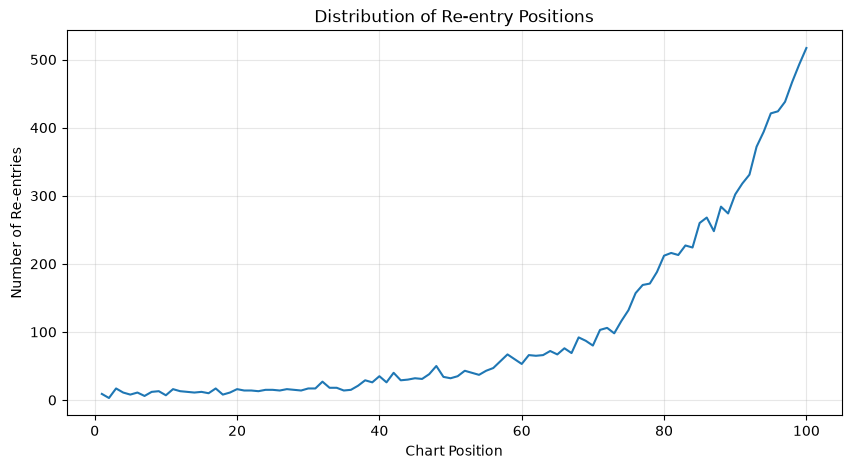

In [118]:
# Re-entry positions

re_position = (re_entry_history['Position']
               .value_counts()
               .sort_index()
               )

plt.figure(figsize=(10, 5))

plt.plot(re_position.index,
         re_position.values)

plt.title('Distribution of Re-entry Positions')
plt.xlabel('Chart Position')
plt.ylabel('Number of Re-entries')

plt.grid(alpha=0.3)

plt.show()

### Explore Re-entry Frequencies

The number of re-entries is calculated for each song to examine how frequently
songs return to the charts.

The resulting distribution highlights whether repeated chart re-entries are
common or represent exceptional cases.

In [119]:
re_counts = re_entries.value_counts().sort_index()
re_counts

1     4682
2     1000
3      303
4      128
5       73
6       41
7       35
8       26
9       17
10      10
11      15
12       6
13       9
14       5
15       1
16       4
17       7
18       3
19       3
20       2
21       1
24       1
58       1
Name: count, dtype: int64

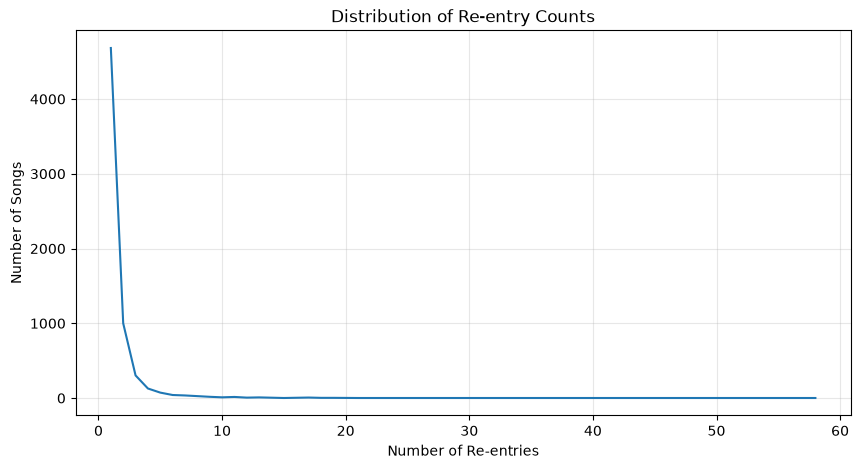

In [120]:
# Re-entry counts

plt.figure(figsize=(10, 5))

plt.plot(re_counts.index,
         re_counts.values)

plt.title('Distribution of Re-entry Counts')
plt.xlabel('Number of Re-entries')
plt.ylabel('Number of Songs')

plt.grid(alpha=0.3)

plt.show()

In [121]:
# Most songs experience only a single chart re-entry, 
# while repeated re-entries are comparatively rare. 
# A small number of songs represent extreme long-term outliers.

### Identify Songs with Frequent Re-entries

Songs with the highest number of chart re-entries are identified to explore
which titles repeatedly return to the charts.

This provides an initial indication of long-term chart longevity.

In [122]:
top_re_songs = (re_entries
                .head(20)
                .rename('number_re_entries')
                .reset_index()
                .merge(songs,
                        on='song_id',
                        how='left')
                )

top_re_songs

,song_id,number_re_entries,Song,Artist
0,24705.0,58,MR BRIGHTSIDE,KILLERS
1,72.0,24,MERRY XMAS EVERYBODY,SLADE
2,929.0,21,THRILLER,MICHAEL JACKSON
3,28523.0,20,USE SOMEBODY,KINGS OF LEON
4,12532.0,20,STAY ANOTHER DAY,EAST 17
5,28337.0,19,ONE DAY LIKE THIS,ELBOW
6,26514.0,19,FAIRYTALE OF NEW YORK,POGUES FT KIRSTY MACCOLL
7,2738.0,19,MERRY CHRISTMAS EVERYONE,SHAKIN' STEVENS
8,12558.0,18,ALL I WANT FOR CHRISTMAS IS YOU,MARIAH CAREY
9,16733.0,18,I DON'T WANT TO MISS A THING,AEROSMITH


In [123]:
# Songs with frequent re-entries are predominantly long-lasting classics
# and seasonal titles, particularly Christmas songs.

### Explore Re-entry Activity over Time

The number of chart re-entries is aggregated by calendar year to examine how
re-entry activity changed throughout the observation period.

The resulting time series provides an initial overview of long-term temporal
patterns.

In [124]:
re_per_year = (re_entry_history
               .groupby('Year')
               .size()
               .rename('number_re_entries')
               )

re_per_year

Year
1983     75
1984    148
1985    182
1986    205
1987    130
1988    134
1989    100
1990     86
1991     66
1992     20
1993     24
1994    146
1995    291
1996    332
1997    334
1998    300
1999    376
2000    400
2001    348
2002    287
2003    272
2004    338
2005    204
2006    161
2007    262
2008    320
2009    315
2010    317
2011    426
2012    530
2013    498
2014    354
2015    243
2016    207
2017    269
2018    225
2019    211
2020    244
2021    240
2022    243
2023    307
2024    127
Name: number_re_entries, dtype: int64

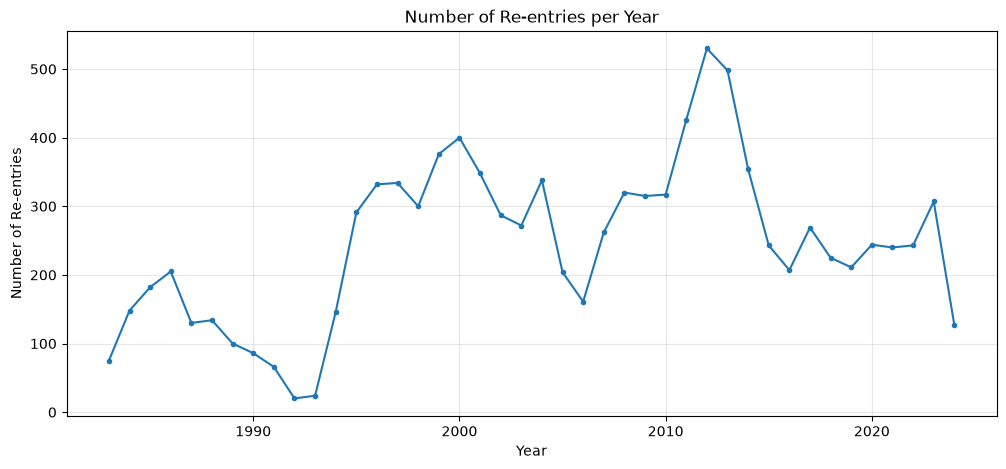

In [125]:
# Re-entries per Year

plt.figure(figsize=(12, 5))

plt.plot(re_per_year.index,
         re_per_year.values,
         marker='o',
         markersize=3)

plt.title('Number of Re-entries per Year')
plt.xlabel('Year')
plt.ylabel('Number of Re-entries')

plt.grid(alpha=0.3)

plt.show()

In [126]:
# The first years should be interpreted with caution because the observation
# period starts in 1983.

# Re-entry activity varies considerably over time. After a decline in the
# early 1990s, the number of re-entries increases substantially and reaches
# its highest levels around 2012.

# Technological changes may have influenced how songs re-enter the charts
# over time and represent a potential direction for further investigation.

### Explore Re-entry Seasonality

The chart week is used to derive the calendar month of each re-entry.

This enables an initial exploration of seasonal patterns in chart re-entries.

In [127]:
re_entry_history['Week'] = pd.to_datetime(re_entry_history['Week'].str.split('-').str[0],
                                            format='%d %B %Y')

re_entry_history['Month'] = (re_entry_history['Week'].dt.month)

re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Week,Year,Decade,Month
64,65.0,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,1983-01-02,1983,1980,1
74,75.0,LET'S GO TO BED,THE CURE,75,LW:RE,1983-01-02,1983,1980,1
89,90.0,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,1983-01-02,1983,1980,1
90,91.0,THE LOOK OF LOVE,ABC,91,LW:RE,1983-01-02,1983,1980,1
93,94.0,CRY BOY CRY,BLUE ZOO,94,LW:RE,1983-01-02,1983,1980,1


In [128]:
re_per_month = (re_entry_history
                .groupby('Month')
                .size()
                .rename('number_re_entries')
                )

re_per_month

Month
1     1494
2      755
3      717
4      703
5      674
6      748
7      836
8      718
9      659
10     758
11     831
12    1404
Name: number_re_entries, dtype: int64

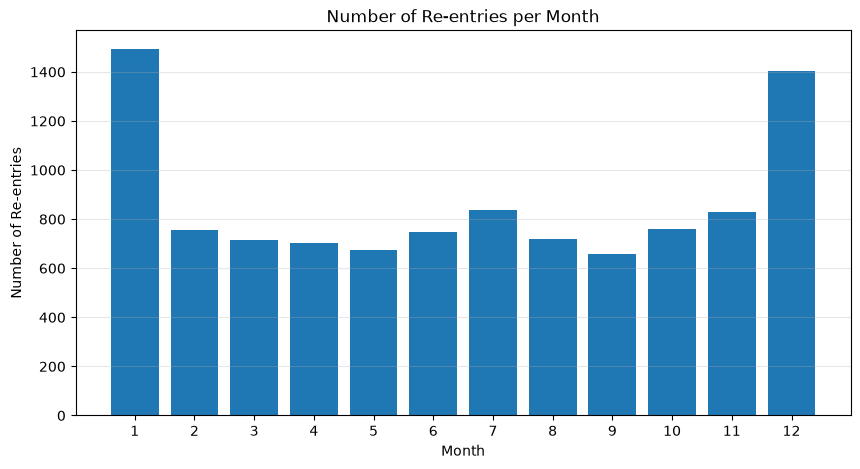

In [129]:
# Re-entries per Month

plt.figure(figsize=(10, 5))

plt.bar(re_per_month.index,
        re_per_month.values)

plt.title('Number of Re-entries per Month')
plt.xlabel('Month')
plt.ylabel('Number of Re-entries')

plt.xticks(range(1, 13))

plt.grid(axis='y', alpha=0.3)

plt.show()

In [130]:
# Re-entry activity shows a clear seasonal pattern. 
# January and December contain substantially more re-entries than the remaining months,
# indicating a strong seasonal influence on chart returns.

### Explore Re-entry Decades

Chart re-entries are aggregated by decade to examine long-term changes in
re-entry activity across different periods.

Since the observation period covers 1983 to March 2024, the first and last
decades are only partially represented and should be interpreted with caution.

In [131]:
re_per_decade = (re_entry_history
                 .groupby('Decade')
                 .size()
                 .rename('number_re_entries')
                )

re_per_decade

Decade
1980     974
1990    1975
2000    2907
2010    3280
2020    1161
Name: number_re_entries, dtype: int64

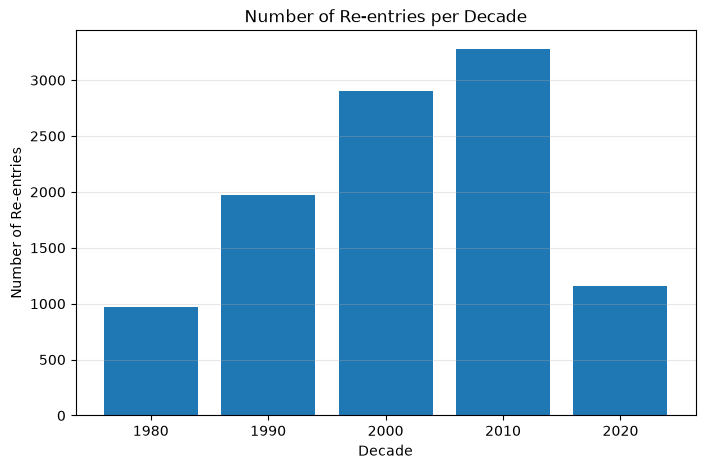

In [132]:
# Re-entries per Decade

plt.figure(figsize=(8, 5))

plt.bar(re_per_decade.index.astype(str),
        re_per_decade.values)

plt.title('Number of Re-entries per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Re-entries')

plt.grid(axis='y', alpha=0.3)

plt.show()

In [133]:
# Re-entry activity increased substantially from the 1980s to the 2010s.
# The lower numbers in the 1980s and 2020s should be interpreted with caution,
# as both decades are only partially covered by the observation period
# (1983–1989 and 2020–March 2024).

### Export Re-entry History

The enriched re-entry dataset is exported for reuse in subsequent analyses.

It contains all observed chart re-entry events together with the derived
temporal variables used throughout this notebook.

In [134]:
re_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Week,Year,Decade,Month
64,65.0,PASS THE DUTCHIE,MUSICAL YOUTH,65,LW:RE,1983-01-02,1983,1980,1
74,75.0,LET'S GO TO BED,THE CURE,75,LW:RE,1983-01-02,1983,1980,1
89,90.0,CAROLINE (LIVE AT THE N.E.C.),STATUS QUO,90,LW:RE,1983-01-02,1983,1980,1
90,91.0,THE LOOK OF LOVE,ABC,91,LW:RE,1983-01-02,1983,1980,1
93,94.0,CRY BOY CRY,BLUE ZOO,94,LW:RE,1983-01-02,1983,1980,1


## Explore New Entries

Chart runs beginning with a new chart entry are extracted into a separate dataset.

This allows the characteristics of new chart runs to be explored independently
from re-entries and provides a complementary perspective on chart dynamics.

In [135]:
new_entry_history = (chart_history[chart_history['Last Week'] == 'LW:New'].copy())

new_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week
37,38.0,DOWN UNDER,MEN AT WORK,38,LW:New,38,1,2 January 1983- 8 January 1983
39,40.0,EUROPEAN FEMALE,THE STRANGLERS,40,LW:New,40,1,2 January 1983- 8 January 1983
49,50.0,STEPPIN' OUT,JOE JACKSON,50,LW:New,50,1,2 January 1983- 8 January 1983
56,57.0,SNOWMAN MELODY,SNOWMEN,57,LW:New,57,1,2 January 1983- 8 January 1983
60,61.0,MY LOVE IS WAITING,MARVIN GAYE,61,LW:New,61,1,2 January 1983- 8 January 1983


In [136]:
print(f'Number of new chart entries: {len(new_entry_history)}')
print(f'Share of new chart entries: {len(new_entry_history) / len(songs):.2%}')

Number of new chart entries: 36401
Share of new chart entries: 99.31%


In [137]:
### Explore New-entry Years

new_entry_history['Year'] = (new_entry_history['Week'].str[-4:].astype(int))

new_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Year
37,38.0,DOWN UNDER,MEN AT WORK,38,LW:New,38,1,2 January 1983- 8 January 1983,1983
39,40.0,EUROPEAN FEMALE,THE STRANGLERS,40,LW:New,40,1,2 January 1983- 8 January 1983,1983
49,50.0,STEPPIN' OUT,JOE JACKSON,50,LW:New,50,1,2 January 1983- 8 January 1983,1983
56,57.0,SNOWMAN MELODY,SNOWMEN,57,LW:New,57,1,2 January 1983- 8 January 1983,1983
60,61.0,MY LOVE IS WAITING,MARVIN GAYE,61,LW:New,61,1,2 January 1983- 8 January 1983,1983


In [138]:
### Explore New-entry Decades

new_entry_history['Decade'] = (new_entry_history['Year'] // 10) * 10

new_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Year,Decade
37,38.0,DOWN UNDER,MEN AT WORK,38,LW:New,38,1,2 January 1983- 8 January 1983,1983,1980
39,40.0,EUROPEAN FEMALE,THE STRANGLERS,40,LW:New,40,1,2 January 1983- 8 January 1983,1983,1980
49,50.0,STEPPIN' OUT,JOE JACKSON,50,LW:New,50,1,2 January 1983- 8 January 1983,1983,1980
56,57.0,SNOWMAN MELODY,SNOWMEN,57,LW:New,57,1,2 January 1983- 8 January 1983,1983,1980
60,61.0,MY LOVE IS WAITING,MARVIN GAYE,61,LW:New,61,1,2 January 1983- 8 January 1983,1983,1980


#### Prepare Calendar Features

The chart week is converted into a datetime format to derive calendar-based variables used in the following analyses.

In [139]:
### Explore New-entry Months

new_entry_history['Week'] = pd.to_datetime(new_entry_history['Week'].str.split('-').str[0], 
                                           format='%d %B %Y')

new_entry_history['Month'] = (new_entry_history['Week'].dt.month)

new_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Year,Decade,Month
37,38.0,DOWN UNDER,MEN AT WORK,38,LW:New,38,1,1983-01-02,1983,1980,1
39,40.0,EUROPEAN FEMALE,THE STRANGLERS,40,LW:New,40,1,1983-01-02,1983,1980,1
49,50.0,STEPPIN' OUT,JOE JACKSON,50,LW:New,50,1,1983-01-02,1983,1980,1
56,57.0,SNOWMAN MELODY,SNOWMEN,57,LW:New,57,1,1983-01-02,1983,1980,1
60,61.0,MY LOVE IS WAITING,MARVIN GAYE,61,LW:New,61,1,1983-01-02,1983,1980,1


### Explore New-entry Positions

The distribution of chart positions is examined to understand where new chart
runs typically begin.

Summary statistics provide an initial overview, while the position distribution
reveals broader patterns across the chart.

In [140]:
# Explore New-Positions

new_entry_history['Position'].describe()

count    36401.000000
mean        53.597264
std         29.623690
min          1.000000
25%         28.000000
50%         55.000000
75%         80.000000
max        100.000000
Name: Position, dtype: float64

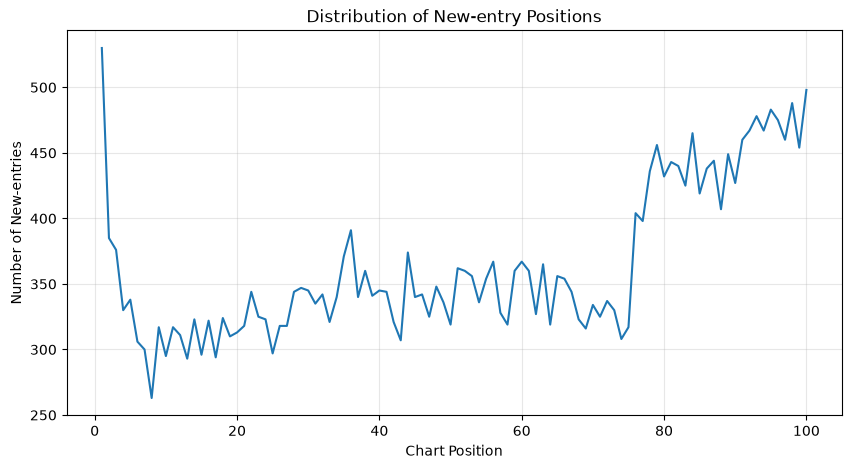

In [141]:
# New-entry positions

new_position = (new_entry_history['Position']
               .value_counts()
               .sort_index()
               )

plt.figure(figsize=(10, 5))

plt.plot(new_position.index,
         new_position.values)

plt.title('Distribution of New-entry Positions')
plt.xlabel('Chart Position')
plt.ylabel('Number of New-entries')

plt.grid(alpha=0.3)

plt.show()

In [142]:
# New entries occur across the entire chart.
# Position 1 forms a noticeable peak, while another concentration appears
# in the lower chart positions.

# Whether these patterns changed over time will be investigated later.

In [143]:
new_position.head(10)

Position
1     530
2     385
3     376
4     330
5     338
6     306
7     300
8     263
9     317
10    295
Name: count, dtype: int64

#### Validate Multiple New Chart Runs

Almost all songs begin only one chart run.

A very small number of songs start multiple new chart runs. This indicates that the same song can receive more than one `LW:New` entry in the dataset.

The chart rules leading to a new chart run remain subject to further investigation.

In [144]:
new_entries = (chart_history[chart_history['Last Week'] == 'LW:New']
               .groupby('song_id')
               .size()
            )

new_entries.value_counts()

1    35692
2      333
3       11
4        1
Name: count, dtype: int64

In [145]:
top_new_songs = (new_entries[new_entries > 1]
                 .rename('number_new_entries')
                 .reset_index()
                 .merge(songs,
                        on='song_id',
                        how='left')
                .sort_values('number_new_entries',
                             ascending=False)
                )

top_new_songs.head()

,song_id,number_new_entries,Song,Artist
107,12212.0,4,SO IN LOVE WITH YOU,DUKE
99,11845.0,3,FEEL WHAT YOU WANT,KRISTINE W
0,143.0,3,1999,PRINCE
90,11555.0,3,YOU GOTTA BE,DES'REE
123,12652.0,3,I LUV U BABY,ORIGINAL


In [146]:
# Prince's "1999" illustrates that the same song can begin 
# multiple independent chart runs in the dataset.

chart_history[chart_history['song_id'] == 143]

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week
279,143.0,1999,PRINCE,80,LW:New,80,1,16 January 1983- 22 January 1983
346,143.0,1999,PRINCE,48,LW:80,48,2,23 January 1983- 29 January 1983
431,143.0,1999,PRINCE,33,LW:48,33,3,30 January 1983- 5 February 1983
523,143.0,1999,PRINCE,25,LW:33,25,4,6 February 1983- 12 February 1983
624,143.0,1999,PRINCE,26,LW:25,25,5,13 February 1983- 19 February 1983
732,143.0,1999,PRINCE,34,LW:26,25,6,20 February 1983- 26 February 1983
833,143.0,1999,PRINCE,35,LW:34,25,7,27 February 1983- 5 March 1983
952,143.0,1999,PRINCE,54,LW:35,25,8,6 March 1983- 12 March 1983
79437,143.0,1999,PRINCE,49,LW:51,10,7,26 December 1999- 1 January 2000
79498,143.0,1999,PRINCE,10,LW:New,10,1,3 January 1999- 9 January 1999


In [147]:
# A small number of songs appear multiple times as chart "new" entries.
# This suggests that "LW:New" marks the beginning of a new chart run,
# rather than the first chart appearance of a song overall.
#
# The exact chart rules remain subject to further investigation.

In [148]:
validation = (chart_history.groupby('Last Week')['Weeks on Chart']
              .agg(['min', 'max', 'median'])
              )

validation.loc[['LW:New', 'LW:RE']]

,min,max,median
Last Week,,,
LW:New,1,1,1.0
LW:RE,2,391,11.0


In [149]:
# Validation:
# All NEW entries start with Weeks on Chart = 1,
# whereas RE entries continue an existing chart run.
#
# The conditions under which a completely new chart run begins
# require further investigation.

### Explore New-entry Years

The annual number of new chart entries is examined to identify long-term
changes in chart dynamics over time.

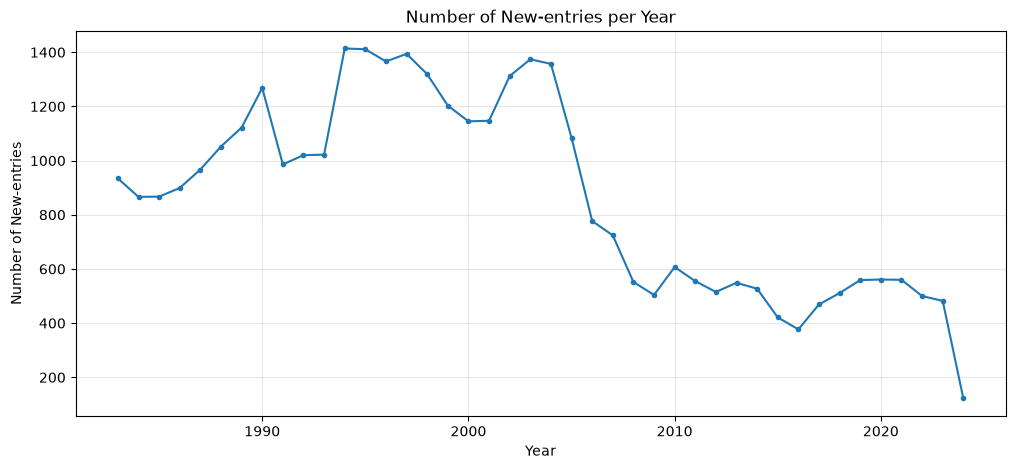

In [150]:
# New entries per year

new_per_year = (new_entry_history
               .groupby('Year')
               .size()
               .rename('number_new_entries')
               )

plt.figure(figsize=(12, 5))

plt.plot(new_per_year.index,
         new_per_year.values,
         marker='o',
         markersize=3)

plt.title('Number of New-entries per Year')
plt.xlabel('Year')
plt.ylabel('Number of New-entries')

plt.grid(alpha=0.3)

plt.show()

In [151]:
# The first years should be interpreted with caution because the observation
# period starts in 1983.

# New-entry activity increases during the 1990s before declining markedly
# from the mid-2000s onwards.

# The reasons behind this long-term trend require further investigation.

### Explore New-entry Seasonality

The monthly distribution of new chart entries is examined to identify
potential seasonal patterns throughout the year.

The results are compared with the previously observed re-entry seasonality.

In [152]:
new_per_month = (new_entry_history
                .groupby('Month')
                .size()
                .rename('number_new_entries')
                )

new_per_month

Month
1     2489
2     2928
3     3439
4     2918
5     3342
6     3151
7     2996
8     3029
9     3257
10    3359
11    3391
12    2102
Name: number_new_entries, dtype: int64

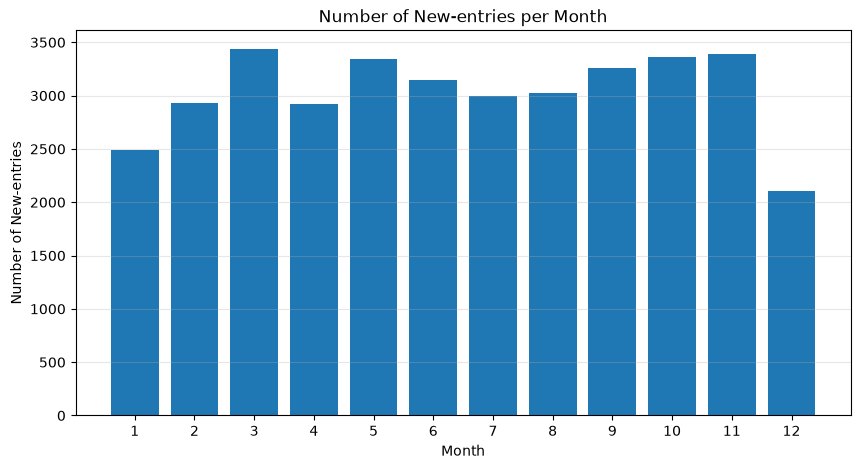

In [153]:
# New-entries per Month

plt.figure(figsize=(10, 5))

plt.bar(new_per_month.index,
        new_per_month.values)

plt.title('Number of New-entries per Month')
plt.xlabel('Month')
plt.ylabel('Number of New-entries')

plt.xticks(range(1, 13))

plt.grid(axis='y', alpha=0.3)

plt.show()

In [154]:
# New-entry activity is distributed much more evenly across the calendar year
# than re-entry activity.
#
# This contrasts with the pronounced winter peak observed for re-entries,
# where January and December dominate the seasonal distribution.

### Explore New-entry Decades

Long-term changes are summarised by decade to reduce year-to-year variation
and highlight broader trends in new chart activity.

#### New chart entries reached their highest levels during the 1990s and remained high throughout the 2000s.

Since the 2010s, the number of new chart entries has declined substantially.

The 2020s should be interpreted with caution because the observation period currently ends in 2024.

In [155]:
new_per_decade = (new_entry_history
                 .groupby('Decade')
                 .size()
                 .rename('number_new_entries')
                )

new_per_decade

Decade
1980     6707
1990    12403
2000     9976
2010     5090
2020     2225
Name: number_new_entries, dtype: int64

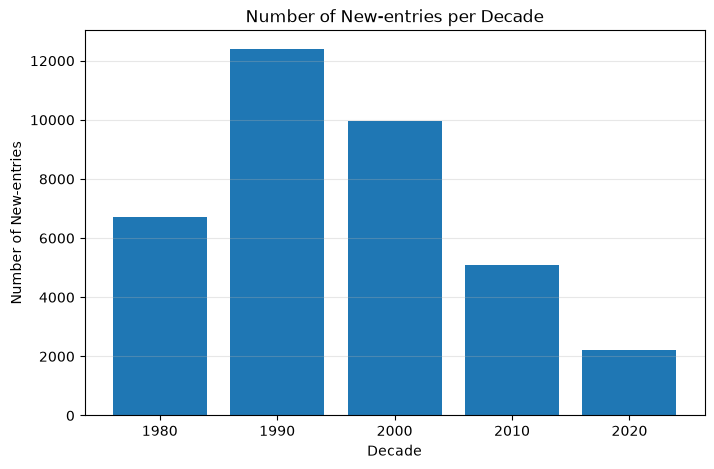

In [156]:
# New-entries per Decade

plt.figure(figsize=(8, 5))

plt.bar(new_per_decade.index.astype(str),
        new_per_decade.values)

plt.title('Number of New-entries per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of New-entries')

plt.grid(axis='y', alpha=0.3)

plt.show()

In [157]:
# The 2020s should be interpreted with caution, as the observation period currently ends in 2024.

### Export New-entry History

The enriched new-entry dataset is exported for reuse in subsequent analyses.

It contains all observed new chart entries together with the derived
temporal variables used throughout this notebook.

In [158]:
new_entry_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Year,Decade,Month
37,38.0,DOWN UNDER,MEN AT WORK,38,LW:New,38,1,1983-01-02,1983,1980,1
39,40.0,EUROPEAN FEMALE,THE STRANGLERS,40,LW:New,40,1,1983-01-02,1983,1980,1
49,50.0,STEPPIN' OUT,JOE JACKSON,50,LW:New,50,1,1983-01-02,1983,1980,1
56,57.0,SNOWMAN MELODY,SNOWMEN,57,LW:New,57,1,1983-01-02,1983,1980,1
60,61.0,MY LOVE IS WAITING,MARVIN GAYE,61,LW:New,61,1,1983-01-02,1983,1980,1


## Explore Chart Duration

Chart duration is defined as the number of weeks a song remains in the UK Top 100.

The following analyses examine the distribution of chart longevity and explore
whether chart duration has changed over time.

In [159]:
chart_history['Weeks on Chart'].describe()

count    210882.000000
mean         10.096713
std          17.379638
min           1.000000
25%           2.000000
50%           5.000000
75%          11.000000
max         403.000000
Name: Weeks on Chart, dtype: float64

In [160]:
chart_history['Weeks on Chart'].value_counts().sort_index().head()

Weeks on Chart
1    36401
2    27965
3    19475
4    15527
5    12841
Name: count, dtype: int64

#### How does Week on Charts count?

In [161]:
print(f'Weeks on chart maximum: {chart_history['Weeks on Chart'].max()}')

Weeks on chart maximum: 403


In [162]:
weeks_on_charts_max = (chart_history['Weeks on Chart'] == chart_history['Weeks on Chart'].max())

chart_history.loc[weeks_on_charts_max]

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week
210847,24705.0,MR BRIGHTSIDE,KILLERS,66,LW:65,10,403,29 March 2024- 4 April 2024


In [163]:
song = chart_history.loc[chart_history['Weeks on Chart'].idxmax(), 'song_id']

chart_history[chart_history['song_id'] == song]

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week
107593,24705.0,MR BRIGHTSIDE,KILLERS,10,LW:New,10,1,30 May 2004- 5 June 2004
107709,24705.0,MR BRIGHTSIDE,KILLERS,26,LW:10,10,2,6 June 2004- 12 June 2004
107821,24705.0,MR BRIGHTSIDE,KILLERS,38,LW:26,10,3,13 June 2004- 19 June 2004
107943,24705.0,MR BRIGHTSIDE,KILLERS,60,LW:38,10,4,20 June 2004- 26 June 2004
110683,24705.0,MR BRIGHTSIDE,KILLERS,100,LW:RE,10,5,26 December 2004- 1 January 2005
...,...,...,...,...,...,...,...,...
210451,24705.0,MR BRIGHTSIDE,KILLERS,70,LW:71,10,399,1 March 2024- 7 March 2024
210542,24705.0,MR BRIGHTSIDE,KILLERS,61,LW:70,10,400,8 March 2024- 14 March 2024
210644,24705.0,MR BRIGHTSIDE,KILLERS,63,LW:61,10,401,15 March 2024- 21 March 2024
210746,24705.0,MR BRIGHTSIDE,KILLERS,65,LW:63,10,402,22 March 2024- 28 March 2024


In [164]:
# Validation:
# Weeks on Chart counts the cumulative number of weeks
# a song has spent in the charts.
#
# Re-entry weeks continue the existing count rather than restarting it.

In [165]:
# Is really one week missing in this history?

mr_brightside = chart_history[chart_history['song_id'] == song]

print(f'Maximum Weeks on Chart - Mr Brightside: {mr_brightside["Weeks on Chart"].max()}')
print(f'Number of chart appearances - Mr Brightside: {len(mr_brightside)}')

Maximum Weeks on Chart - Mr Brightside: 403
Number of chart appearances - Mr Brightside: 402


In [166]:
print(f'Example song: {mr_brightside.iloc[0]["Song"]} - {mr_brightside.iloc[0]["Artist"]}')
print(f'Chart weeks counted: {mr_brightside["Weeks on Chart"].max()}')
print(f'Rows in dataset   : {len(mr_brightside)}')

Example song: MR BRIGHTSIDE - KILLERS
Chart weeks counted: 403
Rows in dataset   : 402


In [167]:
mr_brightside[['Week', 'Weeks on Chart']].tail(20)

,Week,Weeks on Chart
208538,20 October 2023- 26 October 2023,384
208635,27 October 2023- 2 November 2023,385
208734,3 November 2023- 9 November 2023,386
208836,10 November 2023- 16 November 2023,387
208938,17 November 2023- 23 November 2023,388
209051,24 November 2023- 30 November 2023,389
209171,1 December 2023- 7 December 2023,390
209612,5 January 2024- 11 January 2024,391
209724,12 January 2024- 18 January 2024,392
209829,19 January 2024- 25 January 2024,393


In [168]:
# Validation:
# Weeks on Chart counts only the weeks in which a song actually appears in the UK Top 100.
#
# Time spent outside the chart is not included in the count.
# Re-entry weeks therefore continue the existing chart-week count.

In [169]:
# Explore Calendar Weeks

chart_history['Week Start'] = pd.to_datetime(chart_history['Week'].str.split('-').str[0], format='%d %B %Y')

chart_history['Calendar Week'] = chart_history['Week Start'].dt.isocalendar().week
chart_history = chart_history.drop(columns=['Week Start'])
chart_history.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week
0,1.0,SAVE YOUR LOVE,RENEE AND RENATO,1,LW:1,1,11,2 January 1983- 8 January 1983,52
1,2.0,YOU CAN'T HURRY LOVE,PHIL COLLINS,2,LW:6,2,6,2 January 1983- 8 January 1983,52
2,3.0,A WINTER'S TALE,DAVID ESSEX,3,LW:7,3,5,2 January 1983- 8 January 1983,52
3,4.0,BEST YEARS OF OUR LIVES,MODERN ROMANCE,4,LW:8,4,9,2 January 1983- 8 January 1983,52
4,5.0,OUR HOUSE,MADNESS,5,LW:5,5,7,2 January 1983- 8 January 1983,52


#### Example: Re-entry and cumulative chart weeks

Prince's *1999* illustrates how `Weeks on Chart` continues across
separate chart runs. The `Calendar Week` column allows the chart history
to be sorted chronologically.

In [170]:
prince = chart_history[chart_history['song_id'] == 143].copy()

prince['_sort_week'] = pd.to_datetime(prince['Week'].str.split('-').str[0], format='%d %B %Y')

prince

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week,_sort_week
279,143.0,1999,PRINCE,80,LW:New,80,1,16 January 1983- 22 January 1983,2,1983-01-16
346,143.0,1999,PRINCE,48,LW:80,48,2,23 January 1983- 29 January 1983,3,1983-01-23
431,143.0,1999,PRINCE,33,LW:48,33,3,30 January 1983- 5 February 1983,4,1983-01-30
523,143.0,1999,PRINCE,25,LW:33,25,4,6 February 1983- 12 February 1983,5,1983-02-06
624,143.0,1999,PRINCE,26,LW:25,25,5,13 February 1983- 19 February 1983,6,1983-02-13
732,143.0,1999,PRINCE,34,LW:26,25,6,20 February 1983- 26 February 1983,7,1983-02-20
833,143.0,1999,PRINCE,35,LW:34,25,7,27 February 1983- 5 March 1983,8,1983-02-27
952,143.0,1999,PRINCE,54,LW:35,25,8,6 March 1983- 12 March 1983,9,1983-03-06
79437,143.0,1999,PRINCE,49,LW:51,10,7,26 December 1999- 1 January 2000,51,1999-12-26
79498,143.0,1999,PRINCE,10,LW:New,10,1,3 January 1999- 9 January 1999,53,1999-01-03


## Identify individual chart runs

`Weeks on Chart` counts the cumulative number of weeks a song has spent
in the charts. To analyse the duration of individual chart runs,
the chart history is copied and separate chart runs are identified.

In [171]:
chart_duration = chart_history.copy()
chart_duration.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week
0,1.0,SAVE YOUR LOVE,RENEE AND RENATO,1,LW:1,1,11,2 January 1983- 8 January 1983,52
1,2.0,YOU CAN'T HURRY LOVE,PHIL COLLINS,2,LW:6,2,6,2 January 1983- 8 January 1983,52
2,3.0,A WINTER'S TALE,DAVID ESSEX,3,LW:7,3,5,2 January 1983- 8 January 1983,52
3,4.0,BEST YEARS OF OUR LIVES,MODERN ROMANCE,4,LW:8,4,9,2 January 1983- 8 January 1983,52
4,5.0,OUR HOUSE,MADNESS,5,LW:5,5,7,2 January 1983- 8 January 1983,52


In [172]:
# Sort chart history chronologically by song and week

chart_duration['_Week Start'] = pd.to_datetime(chart_duration['Week'].str.split('-').str[0], format='%d %B %Y')

chart_duration = (chart_duration
                  .sort_values(['song_id', '_Week Start'])
                  .drop(columns='_Week Start'))
chart_duration.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week
0,1.0,SAVE YOUR LOVE,RENEE AND RENATO,1,LW:1,1,11,2 January 1983- 8 January 1983,52
102,1.0,SAVE YOUR LOVE,RENEE AND RENATO,3,LW:1,1,12,9 January 1983- 15 January 1983,1
211,1.0,SAVE YOUR LOVE,RENEE AND RENATO,13,LW:3,1,13,16 January 1983- 22 January 1983,2
318,1.0,SAVE YOUR LOVE,RENEE AND RENATO,20,LW:13,1,14,23 January 1983- 29 January 1983,3
438,1.0,SAVE YOUR LOVE,RENEE AND RENATO,40,LW:20,1,15,30 January 1983- 5 February 1983,4


In [173]:
# Explore new entries and re-entries

chart_duration.loc[chart_duration['Last Week'].isin(['LW:New', 'LW:RE'])].head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week
149375,5.0,OUR HOUSE,MADNESS,92,LW:RE,5,14,10 June 2012- 16 June 2012,23
150382,5.0,OUR HOUSE,MADNESS,99,LW:RE,5,15,19 August 2012- 25 August 2012,33
1492,6.0,TIME (CLOCK OF THE HEART),CULTURE CLUB,94,LW:RE,3,13,10 April 1983- 16 April 1983,14
37,38.0,DOWN UNDER,MEN AT WORK,38,LW:New,38,1,2 January 1983- 8 January 1983,52
39,40.0,EUROPEAN FEMALE,THE STRANGLERS,40,LW:New,40,1,2 January 1983- 8 January 1983,52


### Identify songs without a new entry or re-entry

Not every song in the chart history has an explicit `NEW` or `RE`
entry. These songs need to be identified before defining their chart run.

In [174]:
song_has_start = (chart_duration
                  .groupby('song_id')['Last Week']
                  .apply(lambda x: x.isin(['LW:New', 'LW:RE']).any())
                  )

song_has_start.value_counts()

Last Week
True     36393
False      262
Name: count, dtype: int64

In [175]:
songs_without_start = song_has_start[~song_has_start].index

chart_duration.loc[chart_duration['song_id'].isin(songs_without_start), :].head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week
0,1.0,SAVE YOUR LOVE,RENEE AND RENATO,1,LW:1,1,11,2 January 1983- 8 January 1983,52
102,1.0,SAVE YOUR LOVE,RENEE AND RENATO,3,LW:1,1,12,9 January 1983- 15 January 1983,1
211,1.0,SAVE YOUR LOVE,RENEE AND RENATO,13,LW:3,1,13,16 January 1983- 22 January 1983,2
318,1.0,SAVE YOUR LOVE,RENEE AND RENATO,20,LW:13,1,14,23 January 1983- 29 January 1983,3
438,1.0,SAVE YOUR LOVE,RENEE AND RENATO,40,LW:20,1,15,30 January 1983- 5 February 1983,4


In [176]:
chart_duration['song_entry'] = (chart_duration
                                .groupby('song_id')
                                .cumcount())

chart_duration.loc[chart_duration['song_id'] == 5,:]

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week,song_entry
4,5.0,OUR HOUSE,MADNESS,5,LW:5,5,7,2 January 1983- 8 January 1983,52,0.0
112,5.0,OUR HOUSE,MADNESS,13,LW:5,5,8,9 January 1983- 15 January 1983,1,1.0
208,5.0,OUR HOUSE,MADNESS,10,LW:13,5,9,16 January 1983- 22 January 1983,2,2.0
319,5.0,OUR HOUSE,MADNESS,21,LW:10,5,10,23 January 1983- 29 January 1983,3,3.0
433,5.0,OUR HOUSE,MADNESS,35,LW:21,5,11,30 January 1983- 5 February 1983,4,4.0
551,5.0,OUR HOUSE,MADNESS,53,LW:35,5,12,6 February 1983- 12 February 1983,5,5.0
671,5.0,OUR HOUSE,MADNESS,73,LW:53,5,13,13 February 1983- 19 February 1983,6,6.0
149375,5.0,OUR HOUSE,MADNESS,92,LW:RE,5,14,10 June 2012- 16 June 2012,23,7.0
150382,5.0,OUR HOUSE,MADNESS,99,LW:RE,5,15,19 August 2012- 25 August 2012,33,8.0


### Identify chart run starts

To analyse the duration of individual chart runs, each song entry is
classified as a `NEW`, `RE`, or `OLD` run start.

In [177]:
chart_duration['Run Start'] = ''

new_week = chart_duration['Last Week'] == 'LW:New'
chart_duration.loc[new_week, 'Run Start'] = 'NEW'

re_week = chart_duration['Last Week'] == 'LW:RE'
chart_duration.loc[re_week, 'Run Start'] = 'RE'

first_entry = chart_duration['song_entry'] == 0
not_new_re = ~chart_duration['Last Week'].isin(['LW:New', 'LW:RE'])
chart_duration.loc[first_entry & not_new_re, 'Run Start'] = 'OLD'

chart_duration.head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week,song_entry,Run Start
0,1.0,SAVE YOUR LOVE,RENEE AND RENATO,1,LW:1,1,11,2 January 1983- 8 January 1983,52,0.0,OLD
102,1.0,SAVE YOUR LOVE,RENEE AND RENATO,3,LW:1,1,12,9 January 1983- 15 January 1983,1,1.0,
211,1.0,SAVE YOUR LOVE,RENEE AND RENATO,13,LW:3,1,13,16 January 1983- 22 January 1983,2,2.0,
318,1.0,SAVE YOUR LOVE,RENEE AND RENATO,20,LW:13,1,14,23 January 1983- 29 January 1983,3,3.0,
438,1.0,SAVE YOUR LOVE,RENEE AND RENATO,40,LW:20,1,15,30 January 1983- 5 February 1983,4,4.0,


In [178]:
chart_duration['Run Start'].value_counts(dropna=False)

Run Start
       163826
NEW     36401
RE      10297
OLD       358
Name: count, dtype: int64

In [179]:
chart_duration.loc[chart_duration['Run Start'] == 'OLD', :].head()

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week,song_entry,Run Start
0,1.0,SAVE YOUR LOVE,RENEE AND RENATO,1,LW:1,1,11,2 January 1983- 8 January 1983,52,0.0,OLD
1,2.0,YOU CAN'T HURRY LOVE,PHIL COLLINS,2,LW:6,2,6,2 January 1983- 8 January 1983,52,0.0,OLD
2,3.0,A WINTER'S TALE,DAVID ESSEX,3,LW:7,3,5,2 January 1983- 8 January 1983,52,0.0,OLD
3,4.0,BEST YEARS OF OUR LIVES,MODERN ROMANCE,4,LW:8,4,9,2 January 1983- 8 January 1983,52,0.0,OLD
4,5.0,OUR HOUSE,MADNESS,5,LW:5,5,7,2 January 1983- 8 January 1983,52,0.0,OLD


In [181]:
chart_duration.loc[chart_duration['song_id'] == 5, :]

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week,song_entry,Run Start
4,5.0,OUR HOUSE,MADNESS,5,LW:5,5,7,2 January 1983- 8 January 1983,52,0.0,OLD
112,5.0,OUR HOUSE,MADNESS,13,LW:5,5,8,9 January 1983- 15 January 1983,1,1.0,
208,5.0,OUR HOUSE,MADNESS,10,LW:13,5,9,16 January 1983- 22 January 1983,2,2.0,
319,5.0,OUR HOUSE,MADNESS,21,LW:10,5,10,23 January 1983- 29 January 1983,3,3.0,
433,5.0,OUR HOUSE,MADNESS,35,LW:21,5,11,30 January 1983- 5 February 1983,4,4.0,
551,5.0,OUR HOUSE,MADNESS,53,LW:35,5,12,6 February 1983- 12 February 1983,5,5.0,
671,5.0,OUR HOUSE,MADNESS,73,LW:53,5,13,13 February 1983- 19 February 1983,6,6.0,
149375,5.0,OUR HOUSE,MADNESS,92,LW:RE,5,14,10 June 2012- 16 June 2012,23,7.0,RE
150382,5.0,OUR HOUSE,MADNESS,99,LW:RE,5,15,19 August 2012- 25 August 2012,33,8.0,RE


### Identify individual chart runs

Each chart run is assigned a unique ID for each song.
The ID increases whenever a new `NEW`, `RE`, or `OLD` run starts.

In [182]:
run_start = chart_duration['Run Start'] != ''

chart_duration['Run ID'] = (run_start.groupby(chart_duration['song_id']).cumsum())
chart_duration.loc[chart_duration['song_id'] == 5,:]

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week,song_entry,Run Start,Run ID
4,5.0,OUR HOUSE,MADNESS,5,LW:5,5,7,2 January 1983- 8 January 1983,52,0.0,OLD,1.0
112,5.0,OUR HOUSE,MADNESS,13,LW:5,5,8,9 January 1983- 15 January 1983,1,1.0,,1.0
208,5.0,OUR HOUSE,MADNESS,10,LW:13,5,9,16 January 1983- 22 January 1983,2,2.0,,1.0
319,5.0,OUR HOUSE,MADNESS,21,LW:10,5,10,23 January 1983- 29 January 1983,3,3.0,,1.0
433,5.0,OUR HOUSE,MADNESS,35,LW:21,5,11,30 January 1983- 5 February 1983,4,4.0,,1.0
551,5.0,OUR HOUSE,MADNESS,53,LW:35,5,12,6 February 1983- 12 February 1983,5,5.0,,1.0
671,5.0,OUR HOUSE,MADNESS,73,LW:53,5,13,13 February 1983- 19 February 1983,6,6.0,,1.0
149375,5.0,OUR HOUSE,MADNESS,92,LW:RE,5,14,10 June 2012- 16 June 2012,23,7.0,RE,2.0
150382,5.0,OUR HOUSE,MADNESS,99,LW:RE,5,15,19 August 2012- 25 August 2012,33,8.0,RE,3.0


### Calculate the duration of individual chart runs

The `Weeks Run` column stores the number of weeks within each individual
chart run.

In [ ]:
chart_duration['Weeks Run'] = 0
chart_duration.loc[chart_duration['song_id'] == 5,:]

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week,song_entry,Run Start,Run ID,Weeks Run
4,5.0,OUR HOUSE,MADNESS,5,LW:5,5,7,2 January 1983- 8 January 1983,52,0.0,OLD,1.0,0
112,5.0,OUR HOUSE,MADNESS,13,LW:5,5,8,9 January 1983- 15 January 1983,1,1.0,,1.0,0
208,5.0,OUR HOUSE,MADNESS,10,LW:13,5,9,16 January 1983- 22 January 1983,2,2.0,,1.0,0
319,5.0,OUR HOUSE,MADNESS,21,LW:10,5,10,23 January 1983- 29 January 1983,3,3.0,,1.0,0
433,5.0,OUR HOUSE,MADNESS,35,LW:21,5,11,30 January 1983- 5 February 1983,4,4.0,,1.0,0
551,5.0,OUR HOUSE,MADNESS,53,LW:35,5,12,6 February 1983- 12 February 1983,5,5.0,,1.0,0
671,5.0,OUR HOUSE,MADNESS,73,LW:53,5,13,13 February 1983- 19 February 1983,6,6.0,,1.0,0
149375,5.0,OUR HOUSE,MADNESS,92,LW:RE,5,14,10 June 2012- 16 June 2012,23,7.0,RE,2.0,0
150382,5.0,OUR HOUSE,MADNESS,99,LW:RE,5,15,19 August 2012- 25 August 2012,33,8.0,RE,3.0,0


In [190]:
# Count the number of weeks in each individual chart run

run_count = chart_duration.groupby(['song_id', 'Run ID'])['Run ID'].transform('count')

run_count[chart_duration['song_id'] == 5]

4         7.0
112       7.0
208       7.0
319       7.0
433       7.0
551       7.0
671       7.0
149375    1.0
150382    1.0
Name: Run ID, dtype: float64

In [191]:
# Store the run duration for new entries and re-entries

new_re = chart_duration['Run Start'].isin(['NEW', 'RE'])

chart_duration.loc[new_re, 'Run Count'] = run_count[new_re]

chart_duration.loc[chart_duration['song_id'] == 5, :]

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week,song_entry,Run Start,Run ID,Weeks Run,Run Count
4,5.0,OUR HOUSE,MADNESS,5,LW:5,5,7,2 January 1983- 8 January 1983,52,0.0,OLD,1.0,0,NaN
112,5.0,OUR HOUSE,MADNESS,13,LW:5,5,8,9 January 1983- 15 January 1983,1,1.0,,1.0,0,NaN
208,5.0,OUR HOUSE,MADNESS,10,LW:13,5,9,16 January 1983- 22 January 1983,2,2.0,,1.0,0,NaN
319,5.0,OUR HOUSE,MADNESS,21,LW:10,5,10,23 January 1983- 29 January 1983,3,3.0,,1.0,0,NaN
433,5.0,OUR HOUSE,MADNESS,35,LW:21,5,11,30 January 1983- 5 February 1983,4,4.0,,1.0,0,NaN
551,5.0,OUR HOUSE,MADNESS,53,LW:35,5,12,6 February 1983- 12 February 1983,5,5.0,,1.0,0,NaN
671,5.0,OUR HOUSE,MADNESS,73,LW:53,5,13,13 February 1983- 19 February 1983,6,6.0,,1.0,0,NaN
149375,5.0,OUR HOUSE,MADNESS,92,LW:RE,5,14,10 June 2012- 16 June 2012,23,7.0,RE,2.0,0,1.0
150382,5.0,OUR HOUSE,MADNESS,99,LW:RE,5,15,19 August 2012- 25 August 2012,33,8.0,RE,3.0,0,1.0


In [ ]:
# Store the run duration for runs already in progress at the start of the dataset

old = chart_duration['Run Start'] == 'OLD'

chart_duration.loc[old, 'Run Count'] = run_count[old]

chart_duration.loc[old, :].head()


,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week,song_entry,Run Start,Run ID,Weeks Run,Run Count
0,1.0,SAVE YOUR LOVE,RENEE AND RENATO,1,LW:1,1,11,2 January 1983- 8 January 1983,52,0.0,OLD,1.0,0,6.0
1,2.0,YOU CAN'T HURRY LOVE,PHIL COLLINS,2,LW:6,2,6,2 January 1983- 8 January 1983,52,0.0,OLD,1.0,0,11.0
2,3.0,A WINTER'S TALE,DAVID ESSEX,3,LW:7,3,5,2 January 1983- 8 January 1983,52,0.0,OLD,1.0,0,6.0
3,4.0,BEST YEARS OF OUR LIVES,MODERN ROMANCE,4,LW:8,4,9,2 January 1983- 8 January 1983,52,0.0,OLD,1.0,0,5.0
4,5.0,OUR HOUSE,MADNESS,5,LW:5,5,7,2 January 1983- 8 January 1983,52,0.0,OLD,1.0,0,7.0


In [ ]:
# Add the cumulative weeks already spent in the charts
# to the weeks counted in the current OLD run.

old_run_count = (chart_duration.loc[old, 'Weeks on Chart']
                 + chart_duration.loc[old, 'Run Count'])
old_run_count.head()

0    17.0
1    17.0
2    11.0
3    14.0
4    14.0
dtype: float64

In [ ]:
# Create a lookup table for the calculated OLD run durations

old_values = chart_duration.loc[old, ['song_id', 'Run ID']].copy()

old_values['OLD Run Count'] = old_run_count

old_values.head()

,song_id,Run ID,OLD Run Count
0,1.0,1.0,17.0
1,2.0,1.0,17.0
2,3.0,1.0,11.0
3,4.0,1.0,14.0
4,5.0,1.0,14.0


In [ ]:
# Create a unique key for each song and chart run

old_values['Run Key'] = (old_values['song_id'].astype(str)
    + '_'
    + old_values['Run ID'].astype(str))
old_values.head()

,song_id,Run ID,OLD Run Count,Run Key
0,1.0,1.0,17.0,1.0_1.0
1,2.0,1.0,17.0,2.0_1.0
2,3.0,1.0,11.0,3.0_1.0
3,4.0,1.0,14.0,4.0_1.0
4,5.0,1.0,14.0,5.0_1.0


In [ ]:
# Create a unique key for each song and chart run

chart_duration['Run Key'] = (chart_duration['song_id'].astype(str)
                             + '_'
                             + chart_duration['Run ID'].astype(str))
chart_duration.loc[chart_duration['song_id'] == 5, :]

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week,song_entry,Run Start,Run ID,Weeks Run,Run Count,Run Key
4,5.0,OUR HOUSE,MADNESS,5,LW:5,5,7,2 January 1983- 8 January 1983,52,0.0,OLD,1.0,0,7.0,5.0_1.0
112,5.0,OUR HOUSE,MADNESS,13,LW:5,5,8,9 January 1983- 15 January 1983,1,1.0,,1.0,0,NaN,5.0_1.0
208,5.0,OUR HOUSE,MADNESS,10,LW:13,5,9,16 January 1983- 22 January 1983,2,2.0,,1.0,0,NaN,5.0_1.0
319,5.0,OUR HOUSE,MADNESS,21,LW:10,5,10,23 January 1983- 29 January 1983,3,3.0,,1.0,0,NaN,5.0_1.0
433,5.0,OUR HOUSE,MADNESS,35,LW:21,5,11,30 January 1983- 5 February 1983,4,4.0,,1.0,0,NaN,5.0_1.0
551,5.0,OUR HOUSE,MADNESS,53,LW:35,5,12,6 February 1983- 12 February 1983,5,5.0,,1.0,0,NaN,5.0_1.0
671,5.0,OUR HOUSE,MADNESS,73,LW:53,5,13,13 February 1983- 19 February 1983,6,6.0,,1.0,0,NaN,5.0_1.0
149375,5.0,OUR HOUSE,MADNESS,92,LW:RE,5,14,10 June 2012- 16 June 2012,23,7.0,RE,2.0,0,1.0,5.0_2.0
150382,5.0,OUR HOUSE,MADNESS,99,LW:RE,5,15,19 August 2012- 25 August 2012,33,8.0,RE,3.0,0,1.0,5.0_3.0


In [ ]:
# Create a mapping from each Run Key to its calculated OLD run duration

old_run_mapping = old_values.set_index('Run Key')['OLD Run Count']
old_run_mapping.head()

Run Key
1.0_1.0    17.0
2.0_1.0    17.0
3.0_1.0    11.0
4.0_1.0    14.0
5.0_1.0    14.0
Name: OLD Run Count, dtype: float64

In [ ]:
# Map the calculated OLD run duration back to all rows of the corresponding run

old_run_values = chart_duration['Run Key'].map(old_run_mapping)
old_run_values[chart_duration['song_id'] == 5]

4         14.0
112       14.0
208       14.0
319       14.0
433       14.0
551       14.0
671       14.0
149375     NaN
150382     NaN
Name: Run Key, dtype: float64

In [ ]:
# Store the calculated OLD run duration for all rows of the OLD run

chart_duration.loc[old, 'Run Count'] = old_run_values[old]
chart_duration[chart_duration['song_id'] == 5]

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week,song_entry,Run Start,Run ID,Weeks Run,Run Count,Run Key
4,5.0,OUR HOUSE,MADNESS,5,LW:5,5,7,2 January 1983- 8 January 1983,52,0.0,OLD,1.0,0,14.0,5.0_1.0
112,5.0,OUR HOUSE,MADNESS,13,LW:5,5,8,9 January 1983- 15 January 1983,1,1.0,,1.0,0,NaN,5.0_1.0
208,5.0,OUR HOUSE,MADNESS,10,LW:13,5,9,16 January 1983- 22 January 1983,2,2.0,,1.0,0,NaN,5.0_1.0
319,5.0,OUR HOUSE,MADNESS,21,LW:10,5,10,23 January 1983- 29 January 1983,3,3.0,,1.0,0,NaN,5.0_1.0
433,5.0,OUR HOUSE,MADNESS,35,LW:21,5,11,30 January 1983- 5 February 1983,4,4.0,,1.0,0,NaN,5.0_1.0
551,5.0,OUR HOUSE,MADNESS,53,LW:35,5,12,6 February 1983- 12 February 1983,5,5.0,,1.0,0,NaN,5.0_1.0
671,5.0,OUR HOUSE,MADNESS,73,LW:53,5,13,13 February 1983- 19 February 1983,6,6.0,,1.0,0,NaN,5.0_1.0
149375,5.0,OUR HOUSE,MADNESS,92,LW:RE,5,14,10 June 2012- 16 June 2012,23,7.0,RE,2.0,0,1.0,5.0_2.0
150382,5.0,OUR HOUSE,MADNESS,99,LW:RE,5,15,19 August 2012- 25 August 2012,33,8.0,RE,3.0,0,1.0,5.0_3.0


In [200]:
chart_duration[chart_duration['Artist'] == 'ABBA']

,song_id,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week,Calendar Week,song_entry,Run Start,Run ID,Weeks Run,Run Count,Run Key
25,26.0,UNDER ATTACK,ABBA,26,LW:26,26,5,2 January 1983- 8 January 1983,52,0.0,OLD,1.0,0,9.0,26.0_1.0
125,26.0,UNDER ATTACK,ABBA,26,LW:26,26,6,9 January 1983- 15 January 1983,1,1.0,,1.0,0,NaN,26.0_1.0
240,26.0,UNDER ATTACK,ABBA,42,LW:26,26,7,16 January 1983- 22 January 1983,2,2.0,,1.0,0,NaN,26.0_1.0
371,26.0,UNDER ATTACK,ABBA,73,LW:42,26,8,23 January 1983- 29 January 1983,3,3.0,,1.0,0,NaN,26.0_1.0
4462,907.0,THANK YOU FOR THE MUSIC,ABBA,64,LW:New,64,1,6 November 1983- 12 November 1983,44,0.0,NEW,1.0,0,6.0,907.0_1.0
4541,907.0,THANK YOU FOR THE MUSIC,ABBA,43,LW:64,43,2,13 November 1983- 19 November 1983,45,1.0,,1.0,0,NaN,907.0_1.0
4631,907.0,THANK YOU FOR THE MUSIC,ABBA,33,LW:43,33,3,20 November 1983- 26 November 1983,46,2.0,,1.0,0,NaN,907.0_1.0
4732,907.0,THANK YOU FOR THE MUSIC,ABBA,34,LW:33,33,4,27 November 1983- 3 December 1983,47,3.0,,1.0,0,NaN,907.0_1.0
4841,907.0,THANK YOU FOR THE MUSIC,ABBA,43,LW:34,33,5,4 December 1983- 10 December 1983,48,4.0,,1.0,0,NaN,907.0_1.0
4955,907.0,THANK YOU FOR THE MUSIC,ABBA,57,LW:43,33,6,11 December 1983- 17 December 1983,49,5.0,,1.0,0,NaN,907.0_1.0


## Export Analysis Datasets

The datasets created during this notebook are exported for reuse in subsequent analyses.

In [201]:
interim_path = project_path / 'data' / 'interim'

re_entry_history.to_csv(interim_path/'re_entry_history.csv', index=False)

new_entry_history.to_csv(interim_path/'new_entry_history.csv', index=False)